# EDA-3: Mengenal processed dataset v2

Notebook ini dibuat untuk membantu kamu memahami processed dataset v2 dengan cara yang lebih mudah diikuti.

Fokusnya:
- mengenali isi `core_v2` dan `expanded_v2`
- memahami arti tiap kolom utama
- melihat kualitas data, freshness, dan pola sederhana
- menangkap apa yang penting untuk eksperimen Prophet berikutnya

Targetnya bukan sekadar audit teknis, tetapi membuat dataset ini terasa lebih akrab dan mudah dibaca.

## Cara Membaca Notebook Ini

Saya susun notebook ini dari yang paling gampang dulu ke yang lebih detail:
1. ringkasan dataset
2. target `y`
3. penjelasan fitur core
4. penjelasan fitur expanded
5. pemeriksaan freshness dan QC
6. hubungan antar fitur
7. kesimpulan praktis

Kalau kamu hanya ingin cepat paham, baca bagian ringkasan, target, dan kesimpulan dulu. Kalau ingin lebih dalam, lanjut ke bagian fitur dan QC.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

def find_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

ROOT = find_root(Path.cwd())
PROCESSED = ROOT / 'data' / 'processed'

core = pd.read_csv(PROCESSED / 'prophet_daily_core_v2.csv', parse_dates=['ds']).sort_values('ds').reset_index(drop=True)
expanded = pd.read_csv(PROCESSED / 'prophet_daily_expanded_v2.csv', parse_dates=['ds']).sort_values('ds').reset_index(drop=True)
metadata = json.loads((PROCESSED / 'prophet_dataset_metadata_v2.json').read_text())

core.shape, expanded.shape

((3726, 8), (3193, 17))

## Gambaran Besar

`core_v2` adalah dataset utama yang paling bersih dan paling panjang.
`expanded_v2` adalah versi yang lebih kaya fitur, tetapi start date-nya lebih lambat karena menunggu data SHFE dan options tersedia.

Secara sederhana:
- `core_v2` = versi aman untuk baseline utama
- `expanded_v2` = versi lebih kaya untuk melihat apakah fitur tambahan benar-benar membantu

In [2]:
summary = pd.DataFrame([
    {
        'dataset': 'core_v2',
        'rows': metadata['core_v2']['rows'],
        'start_date': metadata['core_v2']['start_date'],
        'end_date': metadata['core_v2']['end_date'],
        'n_columns': len(metadata['core_v2']['columns']),
        'model_regressors': ', '.join(metadata['core_v2']['model_regressors']),
    },
    {
        'dataset': 'expanded_v2',
        'rows': metadata['expanded_v2']['rows'],
        'start_date': metadata['expanded_v2']['start_date'],
        'end_date': metadata['expanded_v2']['end_date'],
        'n_columns': len(metadata['expanded_v2']['columns']),
        'model_regressors': ', '.join(metadata['expanded_v2']['model_regressors']),
    },
])
summary

,dataset,rows,start_date,end_date,n_columns,model_regressors
0,core_v2,3726,2011-05-17,2026-03-17,8,"lag1_warehouse_stockclose, lag1_lme_yesterdayo..."
1,expanded_v2,3193,2013-07-02,2026-03-17,17,"lag1_warehouse_stockclose, lag1_lme_yesterdayo..."


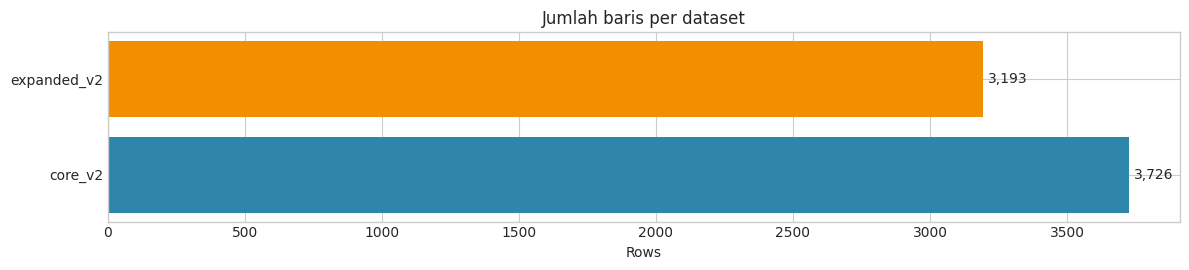

In [3]:
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.barh(['core_v2', 'expanded_v2'], [len(core), len(expanded)], color=['#2E86AB', '#F18F01'])
ax.set_title('Jumlah baris per dataset')
ax.set_xlabel('Rows')
for i, val in enumerate([len(core), len(expanded)]):
    ax.text(val + 20, i, f'{val:,}', va='center')
plt.tight_layout()

## Isi Kolom

Bagian ini penting supaya kita tahu kolom mana yang benar-benar dipakai untuk modeling dan mana yang hanya jadi penanda kualitas data.

- `ds` = tanggal
- `y` = target harga aluminium LME daily
- `lag1_*` = nilai fitur dari hari sebelumnya
- `qc_*` = kolom penanda kualitas / kondisi data

Kalau dilihat dari namanya saja, kita sudah bisa membedakan mana sinyal untuk model dan mana catatan QC.

In [4]:
column_map = pd.DataFrame([
    ['ds', 'tanggal observasi'],
    ['y', 'harga aluminium LME yang menjadi target'],
    ['target_ohlc_has_placeholder_one', 'penanda baris target yang mengandung angka placeholder 1 pada OHLC'],
    ['lag1_warehouse_stockclose', 'stok warehouse LME dari hari sebelumnya'],
    ['lag1_lme_yesterdayofficialusd', 'volume / aktivitas LME yesterday official USD dari hari sebelumnya'],
    ['lag1_fx_eur', 'kurs EUR dari hari sebelumnya'],
    ['lag1_brent_close', 'harga penutupan Brent dari hari sebelumnya'],
    ['lag1_brent_age_days', 'seberapa tua data Brent yang terakhir tersedia'],
    ['lag1_shfe_price_proxy', 'proxy harga SHFE dari hari sebelumnya'],
    ['lag1_shfe_openinterest', 'open interest SHFE dari hari sebelumnya'],
    ['qc_lag1_shfe_rows_per_date', 'penanda jumlah row SHFE yang aktif pada tanggal sumber'],
    ['qc_lag1_shfe_price_from_settlement', 'penanda apakah harga SHFE diganti settlement'],
    ['lag1_opt_core_total', 'total volume options dari hari sebelumnya'],
    ['lag1_opt_official_share', 'porsi official options dari total options'],
    ['lag1_opt_call_share', 'porsi call options dari total options'],
    ['lag1_shfe_age_days', 'seberapa tua data SHFE terakhir tersedia'],
    ['qc_lag1_option_age_days', 'seberapa tua data option terakhir tersedia'],
], columns=['kolom', 'arti sederhana'])
column_map

,kolom,arti sederhana
0,ds,tanggal observasi
1,y,harga aluminium LME yang menjadi target
2,target_ohlc_has_placeholder_one,penanda baris target yang mengandung angka pla...
3,lag1_warehouse_stockclose,stok warehouse LME dari hari sebelumnya
4,lag1_lme_yesterdayofficialusd,volume / aktivitas LME yesterday official USD ...
5,lag1_fx_eur,kurs EUR dari hari sebelumnya
6,lag1_brent_close,harga penutupan Brent dari hari sebelumnya
7,lag1_brent_age_days,seberapa tua data Brent yang terakhir tersedia
8,lag1_shfe_price_proxy,proxy harga SHFE dari hari sebelumnya
9,lag1_shfe_openinterest,open interest SHFE dari hari sebelumnya


## Kualitas Dasar

Di sini kita cek hal paling dasar: apakah ada missing, duplicate, atau tanggal yang kacau.

Jika bagian ini bersih, kita bisa lebih nyaman membaca pola datanya.

In [5]:
quality = pd.DataFrame([
    ['core_v2', len(core), core['ds'].min().date(), core['ds'].max().date(), int(core['ds'].duplicated().sum()), int(core.isna().sum().sum())],
    ['expanded_v2', len(expanded), expanded['ds'].min().date(), expanded['ds'].max().date(), int(expanded['ds'].duplicated().sum()), int(expanded.isna().sum().sum())],
], columns=['dataset', 'rows', 'start_date', 'end_date', 'duplicate_ds', 'missing_cells'])
quality

,dataset,rows,start_date,end_date,duplicate_ds,missing_cells
0,core_v2,3726,2011-05-17,2026-03-17,0,0
1,expanded_v2,3193,2013-07-02,2026-03-17,0,0


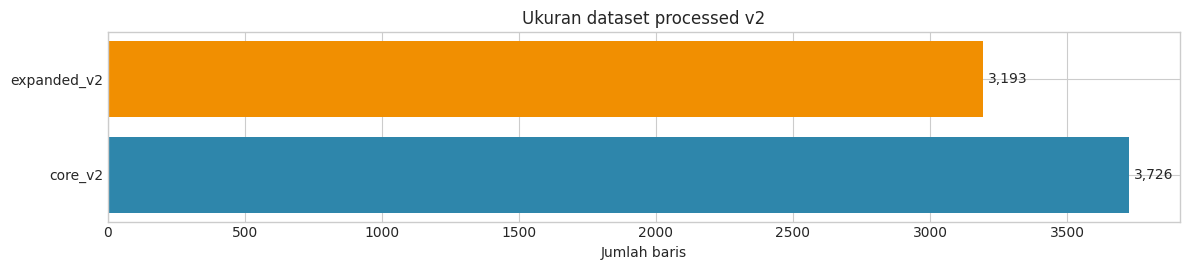

In [6]:
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.barh(['core_v2', 'expanded_v2'], [len(core), len(expanded)], color=['#2E86AB', '#F18F01'])
ax.set_title('Ukuran dataset processed v2')
ax.set_xlabel('Jumlah baris')
for y, n in enumerate([len(core), len(expanded)]):
    ax.text(n + 20, y, f'{n:,}', va='center')
plt.tight_layout()

## Target `y`

Ini adalah jantung dataset. Kita ingin tahu:
- bentuk pergerakan harga
- seberapa volatil
- apakah ada periode tenang dan periode liar

Kalau targetnya sudah kita kenal, fitur lain jadi lebih mudah dipahami.

In [7]:
core_target = core[['ds', 'y']].copy()
core_target['return_pct'] = core_target['y'].pct_change() * 100
core_target['abs_return_pct'] = core_target['return_pct'].abs()
core_target['rolling_30d_abs_return'] = core_target['abs_return_pct'].rolling(30).mean()

target_stats = pd.DataFrame([
    ['min', core_target['y'].min()],
    ['p01', core_target['y'].quantile(0.01)],
    ['median', core_target['y'].median()],
    ['mean', core_target['y'].mean()],
    ['p99', core_target['y'].quantile(0.99)],
    ['max', core_target['y'].max()],
], columns=['metric', 'value'])
target_stats

,metric,value
0,min,1421.500000
1,p01,1458.125000
2,median,2030.750000
3,mean,2101.070585
4,p99,3353.125000
5,max,3984.500000


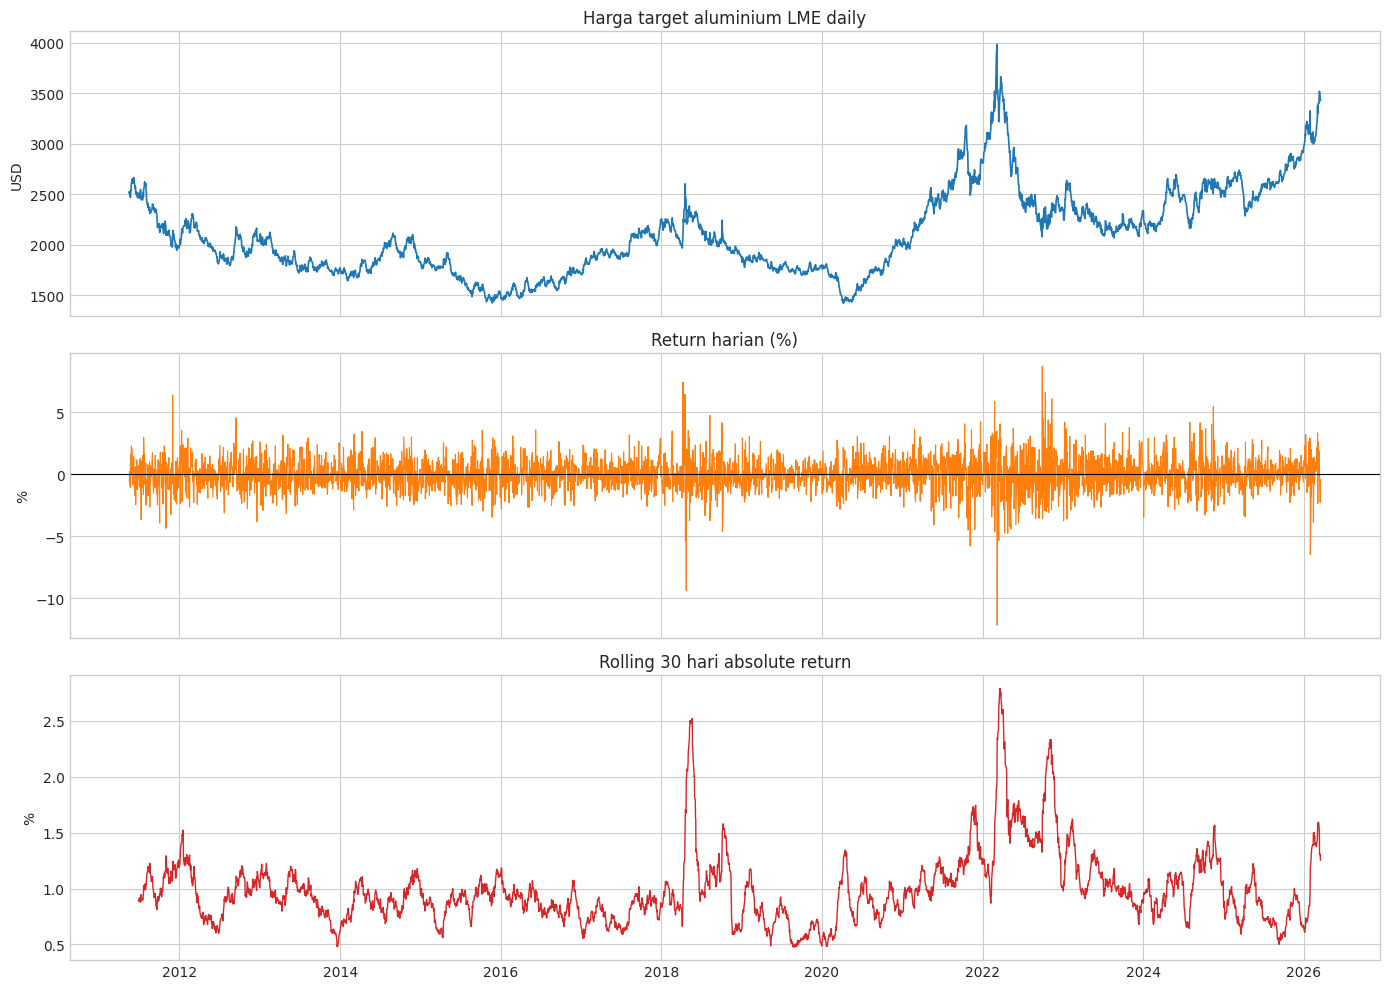

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(core_target['ds'], core_target['y'], color='#1f77b4', linewidth=1.2)
axes[0].set_title('Harga target aluminium LME daily')
axes[0].set_ylabel('USD')

axes[1].plot(core_target['ds'], core_target['return_pct'], color='#ff7f0e', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Return harian (%)')
axes[1].set_ylabel('%')

axes[2].plot(core_target['ds'], core_target['rolling_30d_abs_return'], color='#d62728', linewidth=1.0)
axes[2].set_title('Rolling 30 hari absolute return')
axes[2].set_ylabel('%')

plt.tight_layout()

## Kenapa Ada `core` dan `expanded`?

Ini sering bikin bingung di awal, jadi saya jelaskan sederhana.

- `core_v2` hanya memakai fitur yang lebih panjang dan lebih stabil
- `expanded_v2` menambahkan informasi SHFE dan options supaya kita bisa melihat apakah sinyal tambahan ini membantu

Jadi `expanded_v2` bukan pengganti `core_v2`, melainkan versi yang lebih kaya.

In [9]:
coverage = pd.DataFrame([
    ['core_v2', core['ds'].min(), core['ds'].max(), len(core)],
    ['expanded_v2', expanded['ds'].min(), expanded['ds'].max(), len(expanded)],
], columns=['dataset', 'start', 'end', 'rows'])
coverage

,dataset,start,end,rows
0,core_v2,2011-05-17,2026-03-17,3726
1,expanded_v2,2013-07-02,2026-03-17,3193


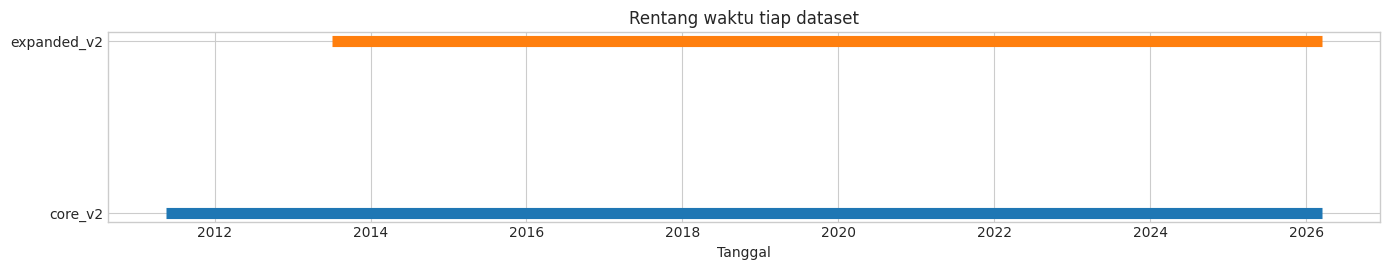

In [10]:
fig, ax = plt.subplots(figsize=(14, 2.8))
for i, row in coverage.iterrows():
    ax.plot([row['start'], row['end']], [i, i], linewidth=8, solid_capstyle='butt', label=row['dataset'])
ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage['dataset'])
ax.set_title('Rentang waktu tiap dataset')
ax.set_xlabel('Tanggal')
plt.tight_layout()

## Core Features

Bagian ini membantu kamu mengenali fitur yang dipakai di `core_v2`.

Yang penting untuk diingat:
- semua fitur ini memakai `lag1`, jadi nilainya berasal dari hari sebelumnya
- tujuan utamanya adalah agar model tidak mencontek data hari yang sama
- ini membuat dataset lebih aman untuk forecasting

In [11]:
core_feature_table = pd.DataFrame([
    ['lag1_warehouse_stockclose', core['lag1_warehouse_stockclose'].min(), core['lag1_warehouse_stockclose'].median(), core['lag1_warehouse_stockclose'].max(), int(core['lag1_warehouse_stockclose'].isna().sum())],
    ['lag1_lme_yesterdayofficialusd', core['lag1_lme_yesterdayofficialusd'].min(), core['lag1_lme_yesterdayofficialusd'].median(), core['lag1_lme_yesterdayofficialusd'].max(), int(core['lag1_lme_yesterdayofficialusd'].isna().sum())],
    ['lag1_fx_eur', core['lag1_fx_eur'].min(), core['lag1_fx_eur'].median(), core['lag1_fx_eur'].max(), int(core['lag1_fx_eur'].isna().sum())],
    ['lag1_brent_close', core['lag1_brent_close'].min(), core['lag1_brent_close'].median(), core['lag1_brent_close'].max(), int(core['lag1_brent_close'].isna().sum())],
    ['lag1_brent_age_days', core['lag1_brent_age_days'].min(), core['lag1_brent_age_days'].median(), core['lag1_brent_age_days'].max(), int(core['lag1_brent_age_days'].isna().sum())],
], columns=['kolom', 'min', 'median', 'max', 'missing'])
core_feature_table

,kolom,min,median,max,missing
0,lag1_warehouse_stockclose,271450.0000,1.356762e+06,5.492325e+06,0
1,lag1_lme_yesterdayofficialusd,70393.0000,2.291080e+05,8.216240e+05,0
2,lag1_fx_eur,0.9566,1.139050e+00,1.466300e+00,0
3,lag1_brent_close,22.7900,7.328000e+01,1.291700e+02,0
4,lag1_brent_age_days,1.0000,1.000000e+00,2.000000e+01,0


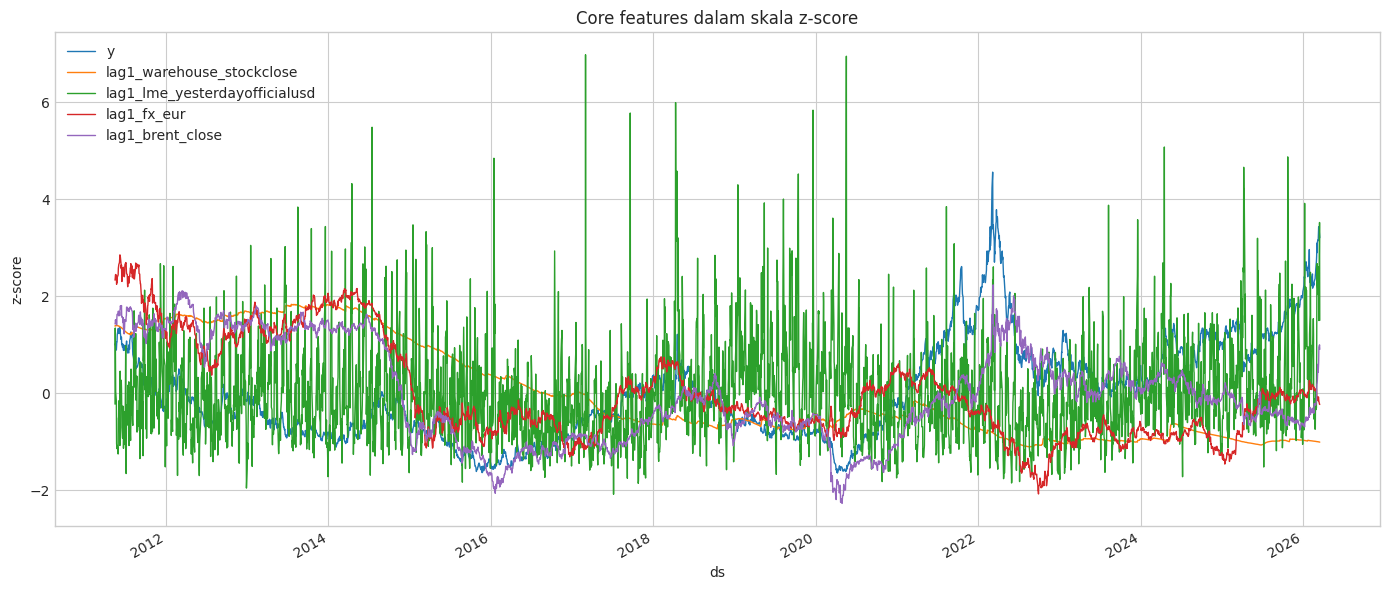

In [12]:
core_plot_cols = ['y', 'lag1_warehouse_stockclose', 'lag1_lme_yesterdayofficialusd', 'lag1_fx_eur', 'lag1_brent_close']
core_scaled = core[['ds', *core_plot_cols]].copy()
for col in core_plot_cols:
    core_scaled[col] = (core_scaled[col] - core_scaled[col].mean()) / core_scaled[col].std()

ax = core_scaled.set_index('ds')[core_plot_cols].plot(figsize=(14, 6), linewidth=1.0)
ax.set_title('Core features dalam skala z-score')
ax.set_ylabel('z-score')
plt.tight_layout()

## Expanded Features

`expanded_v2` menambahkan tiga kelompok informasi:
- SHFE
- option activity
- freshness / QC flags

Bagian ini berguna untuk melihat apakah data tambahan tersebut terasa masuk akal atau terlalu banyak noise.

In [13]:
expanded_feature_table = pd.DataFrame([
    ['lag1_shfe_price_proxy', expanded['lag1_shfe_price_proxy'].min(), expanded['lag1_shfe_price_proxy'].median(), expanded['lag1_shfe_price_proxy'].max(), int(expanded['lag1_shfe_price_proxy'].isna().sum())],
    ['lag1_shfe_openinterest', expanded['lag1_shfe_openinterest'].min(), expanded['lag1_shfe_openinterest'].median(), expanded['lag1_shfe_openinterest'].max(), int(expanded['lag1_shfe_openinterest'].isna().sum())],
    ['lag1_opt_core_total', expanded['lag1_opt_core_total'].min(), expanded['lag1_opt_core_total'].median(), expanded['lag1_opt_core_total'].max(), int(expanded['lag1_opt_core_total'].isna().sum())],
    ['lag1_opt_official_share', expanded['lag1_opt_official_share'].min(), expanded['lag1_opt_official_share'].median(), expanded['lag1_opt_official_share'].max(), int(expanded['lag1_opt_official_share'].isna().sum())],
    ['lag1_opt_call_share', expanded['lag1_opt_call_share'].min(), expanded['lag1_opt_call_share'].median(), expanded['lag1_opt_call_share'].max(), int(expanded['lag1_opt_call_share'].isna().sum())],
    ['lag1_brent_age_days', expanded['lag1_brent_age_days'].min(), expanded['lag1_brent_age_days'].median(), expanded['lag1_brent_age_days'].max(), int(expanded['lag1_brent_age_days'].isna().sum())],
    ['lag1_shfe_age_days', expanded['lag1_shfe_age_days'].min(), expanded['lag1_shfe_age_days'].median(), expanded['lag1_shfe_age_days'].max(), int(expanded['lag1_shfe_age_days'].isna().sum())],
    ['qc_lag1_option_age_days', expanded['qc_lag1_option_age_days'].min(), expanded['qc_lag1_option_age_days'].median(), expanded['qc_lag1_option_age_days'].max(), int(expanded['qc_lag1_option_age_days'].isna().sum())],
], columns=['kolom', 'min', 'median', 'max', 'missing'])
expanded_feature_table

,kolom,min,median,max,missing
0,lag1_shfe_price_proxy,9710.0,14460.000000,25640.0,0
1,lag1_shfe_openinterest,61.0,186416.000000,452531.0,0
2,lag1_opt_core_total,41.0,11510.000000,178604.0,0
3,lag1_opt_official_share,0.0,0.531549,1.0,0
4,lag1_opt_call_share,0.0,0.565945,1.0,0
5,lag1_brent_age_days,1.0,1.000000,20.0,0
6,lag1_shfe_age_days,1.0,1.000000,11.0,0
7,qc_lag1_option_age_days,1.0,1.000000,6.0,0


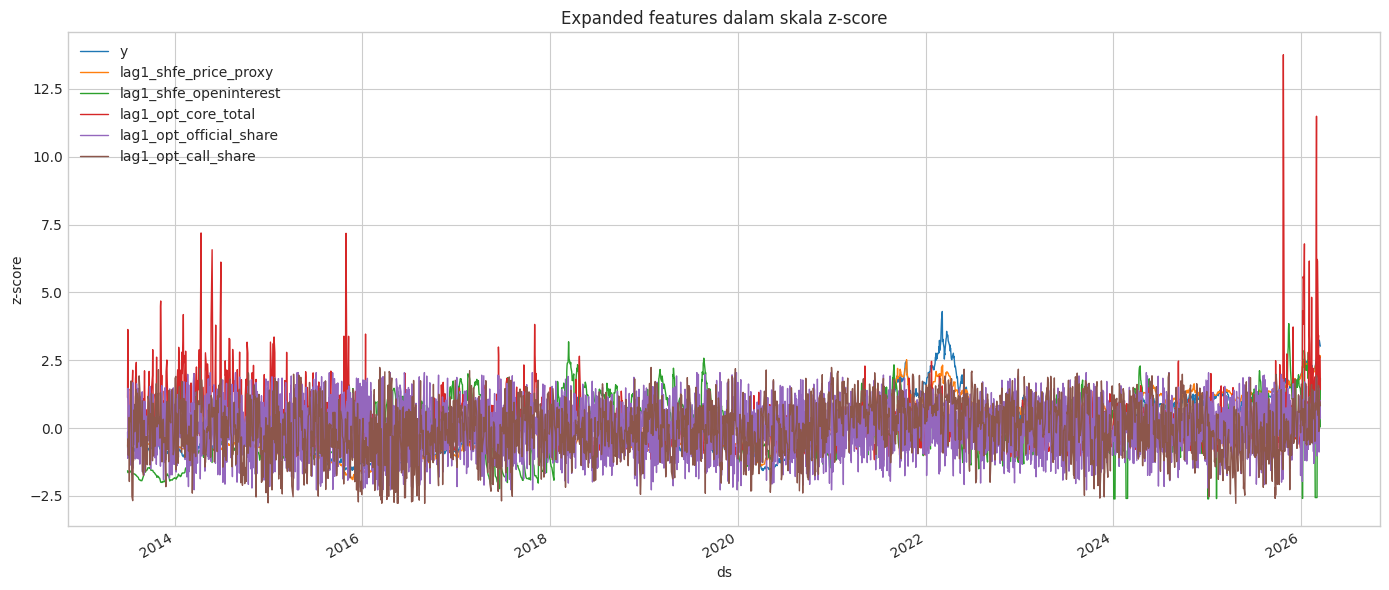

In [14]:
expanded_plot_cols = ['y', 'lag1_shfe_price_proxy', 'lag1_shfe_openinterest', 'lag1_opt_core_total', 'lag1_opt_official_share', 'lag1_opt_call_share']
expanded_scaled = expanded[['ds', *expanded_plot_cols]].copy()
for col in expanded_plot_cols:
    expanded_scaled[col] = (expanded_scaled[col] - expanded_scaled[col].mean()) / expanded_scaled[col].std()

ax = expanded_scaled.set_index('ds')[expanded_plot_cols].plot(figsize=(14, 6), linewidth=1.0)
ax.set_title('Expanded features dalam skala z-score')
ax.set_ylabel('z-score')
plt.tight_layout()

## Freshness / Umur Data

Ini salah satu bagian paling penting.

Kolom `lag1_*_age_days` membantu kita memahami apakah informasi yang dipakai masih fresh atau sudah lama tidak diperbarui.

Semakin besar angka age, semakin perlu hati-hati saat memakai fitur itu untuk forecasting.

In [15]:
age_summary = pd.DataFrame([
    ['lag1_brent_age_days', expanded['lag1_brent_age_days'].value_counts().sort_index().to_dict(), int((expanded['lag1_brent_age_days'] > 3).sum()), int(expanded['lag1_brent_age_days'].max())],
    ['lag1_shfe_age_days', expanded['lag1_shfe_age_days'].value_counts().sort_index().to_dict(), int((expanded['lag1_shfe_age_days'] > 3).sum()), int(expanded['lag1_shfe_age_days'].max())],
    ['qc_lag1_option_age_days', expanded['qc_lag1_option_age_days'].value_counts().sort_index().to_dict(), int((expanded['qc_lag1_option_age_days'] > 3).sum()), int(expanded['qc_lag1_option_age_days'].max())],
], columns=['kolom', 'value_counts', 'count_gt_3', 'max'])
age_summary

,kolom,value_counts,count_gt_3,max
0,lag1_brent_age_days,"{1: 2495, 2: 17, 3: 588, 4: 54, 5: 24, 6: 2, 7...",93,20
1,lag1_shfe_age_days,"{1: 2348, 2: 42, 3: 557, 4: 88, 5: 61, 6: 33, ...",246,11
2,qc_lag1_option_age_days,"{1: 2507, 2: 18, 3: 594, 4: 50, 5: 22, 6: 2}",74,6


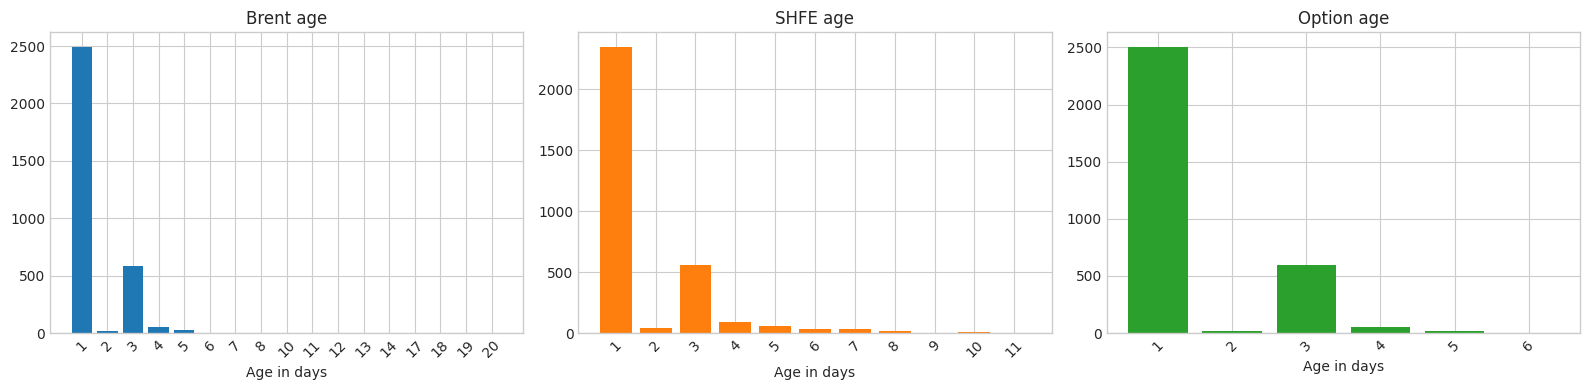

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
age_cols = ['lag1_brent_age_days', 'lag1_shfe_age_days', 'qc_lag1_option_age_days']
titles = ['Brent age', 'SHFE age', 'Option age']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, col, title, color in zip(axes, age_cols, titles, colors):
    counts = expanded[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.set_title(title)
    ax.set_xlabel('Age in days')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

## QC Flags

Kolom QC bukan fitur utama untuk diprediksi, tetapi sangat berguna supaya kita tidak salah membaca data.

Contohnya:
- apakah SHFE punya 2 row pada tanggal tertentu
- apakah harga SHFE diganti settlement
- apakah ada tanggal option yang sangat lama tidak diperbarui

Ini membantu kita menilai seberapa percaya diri kita terhadap fitur-fitur tambahan.

In [17]:
qc_summary = pd.DataFrame([
    ['target_ohlc_has_placeholder_one', int(core['target_ohlc_has_placeholder_one'].sum()), int(expanded['target_ohlc_has_placeholder_one'].sum())],
    ['qc_lag1_shfe_rows_per_date = 2', None, int((expanded['qc_lag1_shfe_rows_per_date'] == 2).sum())],
    ['qc_lag1_shfe_price_from_settlement = 1', None, int((expanded['qc_lag1_shfe_price_from_settlement'] == 1).sum())],
    ['qc_lag1_option_age_days > 0', None, int((expanded['qc_lag1_option_age_days'] > 0).sum())],
], columns=['flag', 'core_v2_count', 'expanded_v2_count'])
qc_summary

,flag,core_v2_count,expanded_v2_count
0,target_ohlc_has_placeholder_one,15.0,15
1,qc_lag1_shfe_rows_per_date = 2,NaN,30
2,qc_lag1_shfe_price_from_settlement = 1,NaN,26
3,qc_lag1_option_age_days > 0,NaN,3193


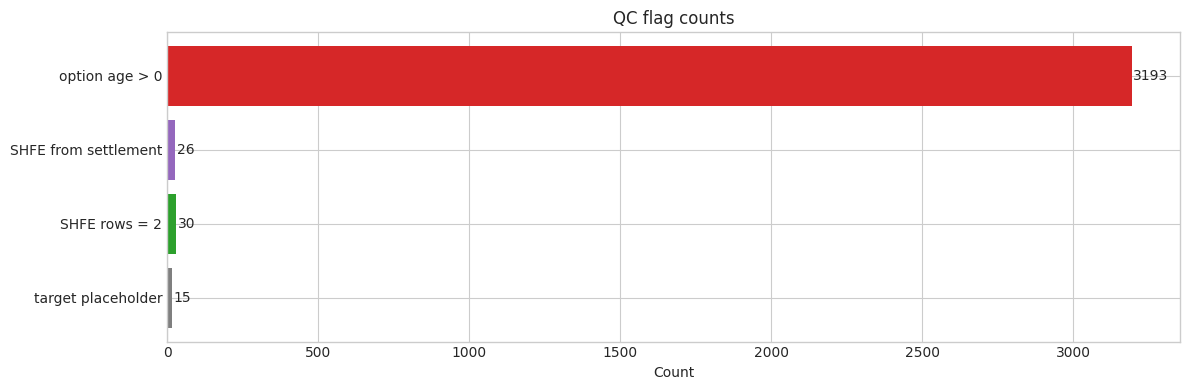

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
flags = [
    ('target placeholder', int(core['target_ohlc_has_placeholder_one'].sum())),
    ('SHFE rows = 2', int((expanded['qc_lag1_shfe_rows_per_date'] == 2).sum())),
    ('SHFE from settlement', int((expanded['qc_lag1_shfe_price_from_settlement'] == 1).sum())),
    ('option age > 0', int((expanded['qc_lag1_option_age_days'] > 0).sum())),
]
labels = [x[0] for x in flags]
values = [x[1] for x in flags]
ax.barh(labels, values, color=['#7f7f7f', '#2ca02c', '#9467bd', '#d62728'])
ax.set_title('QC flag counts')
ax.set_xlabel('Count')
for i, val in enumerate(values):
    ax.text(val + 5, i, str(val), va='center')
plt.tight_layout()

## Hubungan Antar Fitur

Bagian ini membantu kita melihat fitur mana yang mirip satu sama lain.

Kalau dua fitur terlalu mirip, kita tidak perlu memaksa memasukkan semuanya sekaligus ke model.

In [19]:
core_corr_cols = ['y', 'lag1_warehouse_stockclose', 'lag1_lme_yesterdayofficialusd', 'lag1_fx_eur', 'lag1_brent_close', 'lag1_brent_age_days']
expanded_corr_cols = ['y', 'lag1_warehouse_stockclose', 'lag1_lme_yesterdayofficialusd', 'lag1_fx_eur', 'lag1_brent_close', 'lag1_brent_age_days', 'lag1_shfe_price_proxy', 'lag1_shfe_openinterest', 'lag1_opt_core_total', 'lag1_opt_official_share', 'lag1_opt_call_share', 'lag1_shfe_age_days']

core_corr = core[core_corr_cols].corr().round(3)
expanded_corr = expanded[expanded_corr_cols].corr().round(3)

core_corr

,y,lag1_warehouse_stockclose,lag1_lme_yesterdayofficialusd,lag1_fx_eur,lag1_brent_close,lag1_brent_age_days
y,1.000,-0.429,0.030,-0.100,0.323,-0.028
lag1_warehouse_stockclose,-0.429,1.000,-0.015,0.789,0.499,-0.016
lag1_lme_yesterdayofficialusd,0.030,-0.015,1.000,0.049,0.018,-0.027
lag1_fx_eur,-0.100,0.789,0.049,1.000,0.585,-0.013
lag1_brent_close,0.323,0.499,0.018,0.585,1.000,-0.028
lag1_brent_age_days,-0.028,-0.016,-0.027,-0.013,-0.028,1.000


In [20]:
expanded_corr

,y,lag1_warehouse_stockclose,lag1_lme_yesterdayofficialusd,lag1_fx_eur,lag1_brent_close,lag1_brent_age_days,lag1_shfe_price_proxy,lag1_shfe_openinterest,lag1_opt_core_total,lag1_opt_official_share,lag1_opt_call_share,lag1_shfe_age_days
y,1.000,-0.534,0.042,-0.163,0.414,-0.028,0.935,0.206,0.114,0.065,0.227,0.040
lag1_warehouse_stockclose,-0.534,1.000,-0.026,0.701,0.214,-0.009,-0.591,-0.408,0.266,-0.016,-0.080,-0.029
lag1_lme_yesterdayofficialusd,0.042,-0.026,1.000,0.064,0.028,-0.024,0.042,0.115,0.177,0.041,-0.001,-0.040
lag1_fx_eur,-0.163,0.701,0.064,1.000,0.360,-0.004,-0.236,-0.314,0.287,0.021,0.026,-0.013
lag1_brent_close,0.414,0.214,0.028,0.360,1.000,-0.026,0.397,-0.177,0.211,0.032,0.199,0.007
lag1_brent_age_days,-0.028,-0.009,-0.024,-0.004,-0.026,1.000,-0.021,-0.024,-0.010,0.111,0.018,0.463
lag1_shfe_price_proxy,0.935,-0.591,0.042,-0.236,0.397,-0.021,1.000,0.162,0.065,0.063,0.215,0.039
lag1_shfe_openinterest,0.206,-0.408,0.115,-0.314,-0.177,-0.024,0.162,1.000,-0.134,0.004,-0.004,-0.047
lag1_opt_core_total,0.114,0.266,0.177,0.287,0.211,-0.010,0.065,-0.134,1.000,0.081,0.104,0.029
lag1_opt_official_share,0.065,-0.016,0.041,0.021,0.032,0.111,0.063,0.004,0.081,1.000,0.029,0.103


/tmp/ipykernel_105331/1702208025.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


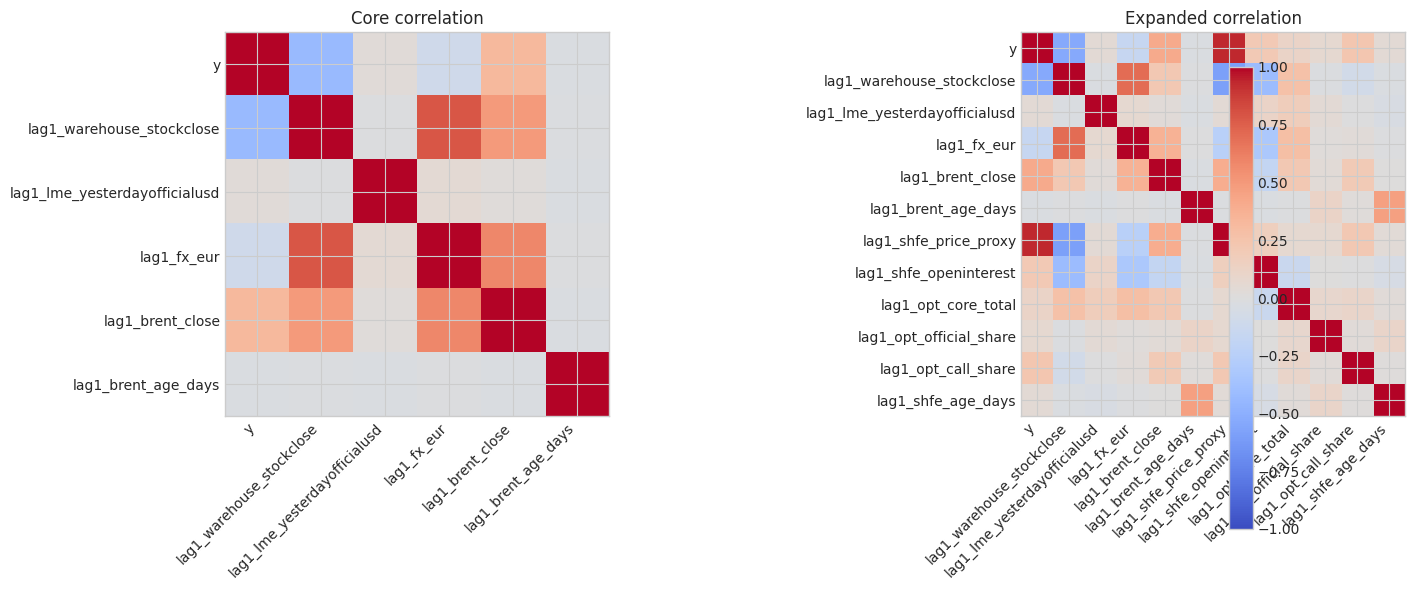

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(core_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(core_corr.columns)))
axes[0].set_xticklabels(core_corr.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(core_corr.index)))
axes[0].set_yticklabels(core_corr.index)
axes[0].set_title('Core correlation')

im1 = axes[1].imshow(expanded_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(expanded_corr.columns)))
axes[1].set_xticklabels(expanded_corr.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(expanded_corr.index)))
axes[1].set_yticklabels(expanded_corr.index)
axes[1].set_title('Expanded correlation')

fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.025, pad=0.04)
plt.tight_layout()

## Contoh Tanggal Penting

Kadang lebih mudah memahami dataset dengan melihat beberapa tanggal yang menonjol.

Saya ambil contoh tanggal yang punya staleness tinggi atau kondisi khusus, supaya kamu bisa melihat bahwa angka-angka tadi benar-benar muncul di data.

In [22]:
interesting_dates = pd.DataFrame([
    ['core brent stale >= 8', core.loc[core['lag1_brent_age_days'] >= 8, 'ds'].dt.strftime('%Y-%m-%d').tolist()],
    ['expanded shfe stale >= 8', expanded.loc[expanded['lag1_shfe_age_days'] >= 8, 'ds'].dt.strftime('%Y-%m-%d').tolist()],
    ['placeholder target rows', core.loc[core['target_ohlc_has_placeholder_one'] == 1, 'ds'].dt.strftime('%Y-%m-%d').tolist()],
], columns=['group', 'dates'])
interesting_dates

,group,dates
0,core brent stale >= 8,"[2019-12-30, 2019-12-31, 2020-01-02, 2020-01-0..."
1,expanded shfe stale >= 8,"[2013-10-08, 2014-02-07, 2014-10-08, 2015-02-2..."
2,placeholder target rows,"[2014-12-02, 2015-01-20, 2015-01-28, 2015-02-0..."


## Inti Yang Perlu Diingat

Kalau semua bagian di atas kamu baca, ada beberapa kesimpulan yang paling penting:

- `core_v2` adalah dataset utama yang paling panjang dan paling aman untuk baseline
- `expanded_v2` lebih kaya, tapi lebih kompleks, jadi cocok untuk eksperimen lanjutan
- semua fitur penting sudah dibuat `lag1`, jadi lebih aman untuk forecasting
- beberapa fitur tambahan punya freshness yang perlu diperhatikan, jadi jangan diperlakukan sama dengan fitur yang selalu fresh
- QC flag penting untuk mencegah kita salah tafsir terhadap baris-baris tertentu

Secara sederhana: dataset ini sudah layak dipakai, tetapi tetap harus dibaca dengan hati-hati.

## Kesimpulan Praktis

Kalau tujuanmu adalah lanjut ke Prophet, urutan pikir yang saya sarankan adalah:
1. mulai dari `core_v2`
2. lihat apakah `expanded_v2` memberi nilai tambah
3. perhatikan freshness feature, terutama Brent dan SHFE
4. jangan memasukkan semua kolom hanya karena tersedia

Notebook ini dibuat supaya kamu bukan cuma tahu tabelnya, tetapi juga paham kenapa tabel itu dibentuk seperti ini.